# Fase 5: Análise Estatística dos Dados

Este notebook reúne as análises estatísticas sobre a base gerada e rotulada nas
fases anteriores: distribuição das amostras por fase do jogo, canais estruturais,
conferência dos scores, cadeias longas e balanceamento dos rótulos.

As análises são feitas sobre os arquivos NPZ presentes na pasta de dados.

In [22]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminho dos dados
DIRETORIO_DADOS = os.path.join(os.getcwd(), 'dados', 'base_limpa')
arquivos_npz = glob.glob(os.path.join(DIRETORIO_DADOS, '*.npz'))

print(f"Encontrados {len(arquivos_npz)} arquivos NPZ.")

Encontrados 108 arquivos NPZ.


In [23]:
from collections import defaultdict

# Estruturas para armazenar as contagens
contagem_bruta = defaultdict(int)
estados_vistos = set()
contagem_distinta = defaultdict(int)

for arquivo in arquivos_npz:
    try:
        dados = np.load(arquivo, allow_pickle=True)
        estados = dados['estados']
        qtd_tracos = dados['qtd_tracos']
        
        for i in range(len(estados)):
            t = int(qtd_tracos[i])
            contagem_bruta[t] += 1
            
            # Hash simples para identificar unicidade
            estado_bytes = estados[i].tobytes()
            if estado_bytes not in estados_vistos:
                estados_vistos.add(estado_bytes)
                contagem_distinta[t] += 1
                
    except Exception as e:
        print(f"Erro ao processar {arquivo}: {e}")

print(f"Leitura concluída!")
print(f"Total de Amostras Brutas: {sum(contagem_bruta.values()):,}")
print(f"Total de Amostras Distintas: {sum(contagem_distinta.values()):,}")

Leitura concluída!
Total de Amostras Brutas: 8,389,692
Total de Amostras Distintas: 6,967,123


In [24]:
# Prepara os dados para o DataFrame
tracos_unicos = sorted(list(set(contagem_bruta.keys()) | set(contagem_distinta.keys())))

df_distribuicao = pd.DataFrame({
    'Quantidade de Traços': tracos_unicos,
    'Amostras Brutas (Total)': [contagem_bruta[t] for t in tracos_unicos],
    'Amostras Distintas (Únicas)': [contagem_distinta[t] for t in tracos_unicos]
})

display(df_distribuicao.head(5))

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,114116,31
1,2,114116,465
2,3,114116,4495
3,4,115069,31465
4,5,188292,156915


In [25]:
display(df_distribuicao)

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,114116,31
1,2,114116,465
2,3,114116,4495
3,4,115069,31465
4,5,188292,156915
5,6,345462,336597
6,7,421682,418974
7,8,448115,447202
8,9,456404,455868
9,10,459424,459057


### Gráfico 1: Volume bruto (incluindo duplicadas)
Mostra o total de matrizes simuladas em cada fase do jogo (quantidade de traços preenchidos), contando as repetições.

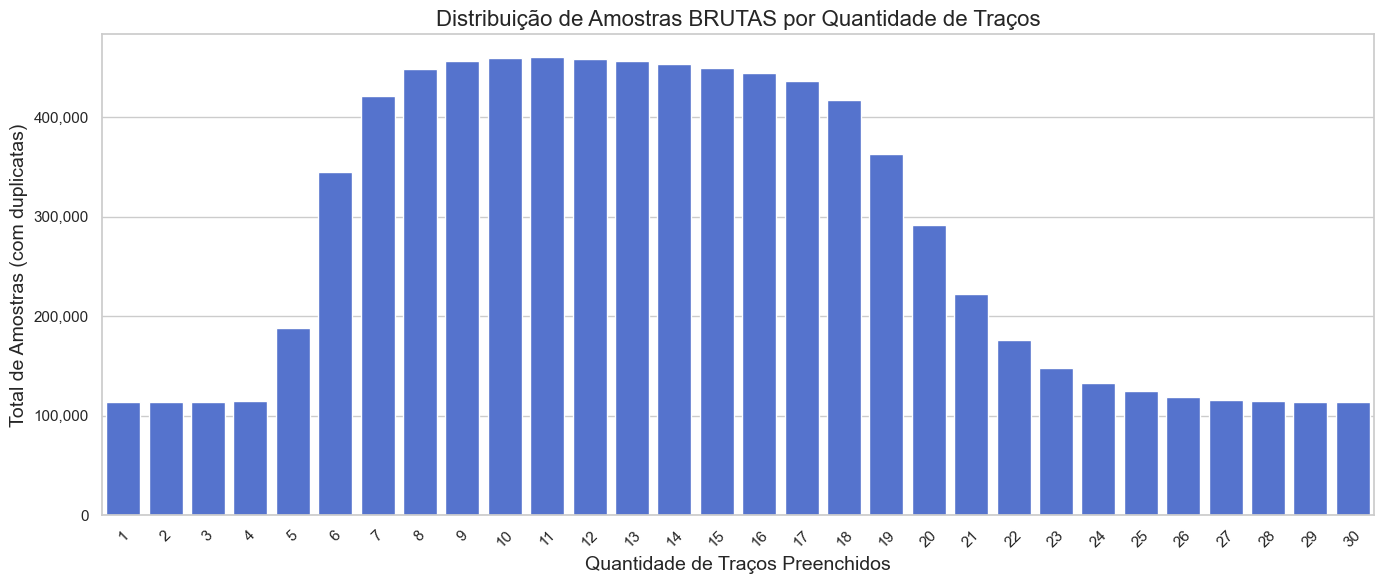

In [26]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Brutas (Total)', color='royalblue')

plt.title('Distribuição de Amostras BRUTAS por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras (com duplicatas)', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gráfico 2: Matrizes distintas (dataset efetivo)
Mostra a base efetiva após remover as duplicatas, ou seja, os tabuleiros distintos por fase do jogo.

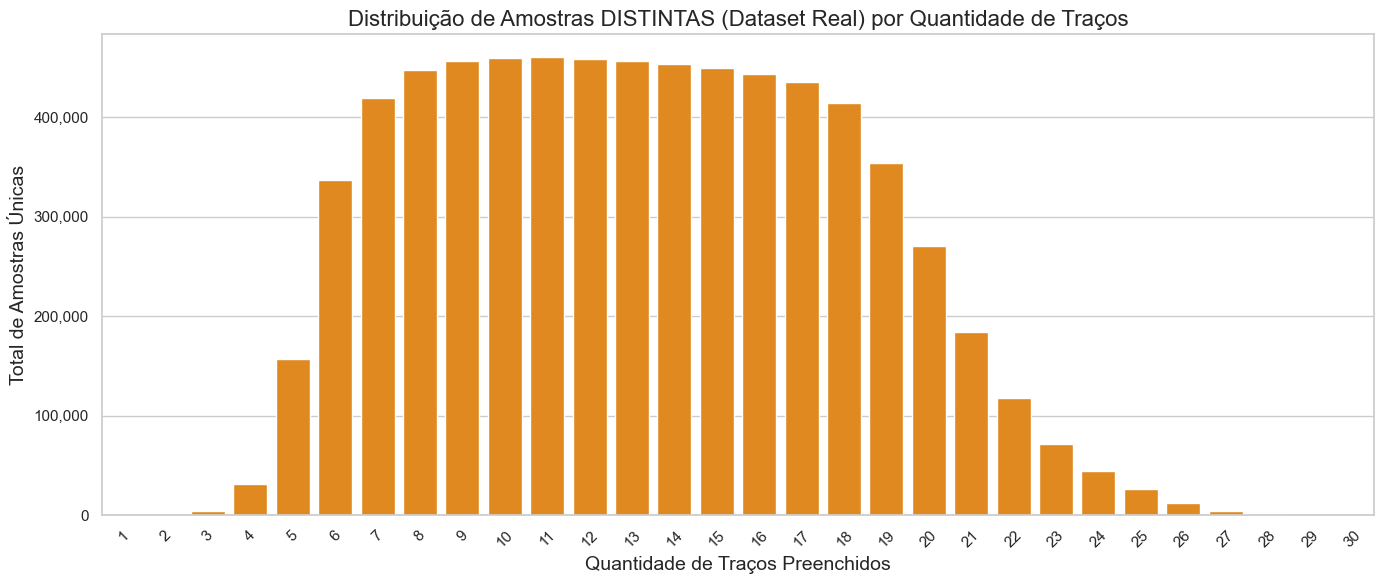

In [27]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Distintas (Únicas)', color='darkorange')

plt.title('Distribuição de Amostras DISTINTAS (Dataset Real) por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras Únicas', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visões Detalhadas

As seções abaixo (canais, conferência de score e cadeias longas) usam todas as amostras rotuladas.

O rótulo de cada estado vem do da base oráculo exata, que resolve o jogo até o fim. Por isso `depth_melhor_jogada`, a profundidade de supervisão, é sempre a distância até o terminal, igual a `31 - qtd_tracos` (o número de traços que ainda faltam). Os scores são os valores exatos do jogo, e não aproximações truncadas.

In [28]:
# Carga mestre: le todos os NPZ uma vez e monta `df` (1 linha por amostra rotulada) e `df_dist` (1 linha por tabuleiro distinto) ===
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INVALIDO = -1e8  # scores invalidos no NPZ valem -1e9

def _to_void(a2d):
    """Cada linha de a2d vira 1 escalar 'void' -> unicidade byte-a-byte (exata e rapida)."""
    a = np.ascontiguousarray(a2d)
    return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).reshape(-1)

_arquivos = sorted(glob.glob(os.path.join(DIRETORIO_DADOS, '*.npz')))

board_v, score_v, valset_v, ch_blocks, dens_blocks = [], [], [], [], []
acc = {k: [] for k in ['qtd_tracos', 'depth_mj', 'melhor_jogada', 'qtd_cadeias',
                       'total_caixas', 'tam_max', 'score_min', 'score_max', 'score_2nd', 'n_validos', 'n_top']}
n_brutas = n_nao_rot = 0
_t0 = time.time()
for arq in _arquivos:
    d = np.load(arq, allow_pickle=True)
    dmj = d['depth_melhor_jogada']
    n_brutas += len(dmj)
    rot = dmj != 0
    n_nao_rot += int((~rot).sum())
    if not rot.any():
        continue
    estados = d['estados'][rot]
    scores = d['score_melhor_jogada'][rot]
    canais = d['canais'][rot]
    n = estados.shape[0]
    valid = scores > INVALIDO

    board_v.append(_to_void(estados.reshape(n, -1)))
    score_v.append(_to_void(scores.reshape(n, -1)))
    sorted_padded = np.sort(np.where(valid, scores, np.inf), axis=1).astype(np.float32)
    valset_v.append(_to_void(sorted_padded.reshape(n, -1)))

    acc['qtd_tracos'].append(d['qtd_tracos'][rot])
    acc['depth_mj'].append(dmj[rot])
    acc['melhor_jogada'].append(np.asarray(d['melhor_jogada'][rot], dtype=object))
    acc['qtd_cadeias'].append(d['qtd_cadeias_longas'][rot])
    acc['total_caixas'].append(d['total_caixas_cadeias_longas'][rot])
    acc['tam_max'].append(d['tamanho_max_cadeia_longa'][rot])
    sc = np.where(valid, scores, np.nan)
    acc['score_max'].append(np.nanmax(sc, axis=1).astype(np.float32))
    acc['score_min'].append(np.nanmin(sc, axis=1).astype(np.float32))
    acc['n_validos'].append(valid.sum(axis=1).astype(np.int16))
    _mx = np.nanmax(sc, axis=1, keepdims=True)
    acc['n_top'].append((sc == _mx).sum(axis=1).astype(np.int16))  # arestas empatadas no topo
    segundo = np.sort(np.where(valid, scores, -np.inf), axis=1)[:, -2]
    acc['score_2nd'].append(np.where(np.isfinite(segundo), segundo, np.nan).astype(np.float32))

    ch_blocks.append(canais.any(axis=(1, 2)))                 # (n,12) bool: canal presente em >=1 celula
    dens_blocks.append(canais.sum(axis=(1, 2)).astype(np.int8))  # (n,12): n de celulas ativas

_, board_id = np.unique(np.concatenate(board_v), return_inverse=True)
_, score_id = np.unique(np.concatenate(score_v), return_inverse=True)
_, valset_id = np.unique(np.concatenate(valset_v), return_inverse=True)
ch_present = np.concatenate(ch_blocks)
ch_dens = np.concatenate(dens_blocks)
del board_v, score_v, valset_v, ch_blocks, dens_blocks

NOMES = list(map(str, np.load(_arquivos[0], allow_pickle=True)['nomes_canais']))

df = pd.DataFrame({
    'board_id': board_id.astype(np.int32),
    'score_id': score_id.astype(np.int32),
    'valset_id': valset_id.astype(np.int32),
    'qtd_tracos': np.concatenate(acc['qtd_tracos']).astype(np.int16),
    'depth_mj': np.concatenate(acc['depth_mj']).astype(np.int16),
    'melhor_jogada': np.concatenate(acc['melhor_jogada']),
    'qtd_cadeias': np.concatenate(acc['qtd_cadeias']).astype(np.int16),
    'total_caixas': np.concatenate(acc['total_caixas']).astype(np.int16),
    'tam_max': np.concatenate(acc['tam_max']).astype(np.int16),
    'score_min': np.concatenate(acc['score_min']),
    'score_max': np.concatenate(acc['score_max']),
    'score_2nd': np.concatenate(acc['score_2nd']),
    'n_validos': np.concatenate(acc['n_validos']).astype(np.int16),
    'n_top': np.concatenate(acc['n_top']).astype(np.int16),
})
df['arestas_livres'] = (31 - df['qtd_tracos']).astype(np.int16)
df['margem'] = df['score_max'] - df['score_2nd']
ch_cols = []
for k, nome in enumerate(NOMES):
    df[f'ch__{nome}'] = ch_present[:, k]
    df[f'dens__{nome}'] = ch_dens[:, k]
    ch_cols.append(f'ch__{nome}')

df_dist = df.drop_duplicates('board_id', keep='first').reset_index(drop=True)

print(f"Amostras brutas totais ...... {n_brutas:,}")
print(f"Nao-rotuladas (excluidas) ... {n_nao_rot:,}  ({100*n_nao_rot/max(n_brutas,1):.1f}%)")
print(f"Amostras rotuladas (df) ..... {len(df):,}")
print(f"Tabuleiros distintos ........ {df['board_id'].nunique():,}")
print(f"Tempo de carga .............. {time.time()-_t0:.1f}s")

Amostras brutas totais ...... 8,389,692
Nao-rotuladas (excluidas) ... 0  (0.0%)
Amostras rotuladas (df) ..... 8,389,692
Tabuleiros distintos ........ 6,967,123
Tempo de carga .............. 31.4s


## 1. Levantamento por Canais

Um canal é considerado **presente** num tabuleiro se está ativo em >=1 das 12 células (4x3). `Qtd. Amostra` conta amostras brutas (com duplicatas); as demais colunas usam **tabuleiros distintos**. `Media celulas ativas` mostra, quando o canal aparece, em quantas das 12 células ele acende (o canal broadcast `paridade_cadeia_longa_impar` acende nas 12).

In [29]:
linhas = []
for c in ch_cols:
    nome = c[len('ch__'):]
    sub = df_dist[df_dist[c]]
    linhas.append({
        'Canal': nome,
        'Qtd. Amostra': int(df[c].sum()),
        'Qtd. Distintas': int(df_dist[c].sum()),
        'Media de Tracos': round(float(sub['qtd_tracos'].mean()), 2) if len(sub) else 0.0,
        'Dist. Melhor Jogada': int(sub['melhor_jogada'].nunique()),
        'Media celulas ativas': round(float(sub[f'dens__{nome}'].mean()), 2) if len(sub) else 0.0,
    })
df_canais = pd.DataFrame(linhas)
display(df_canais)

,Canal,Qtd. Amostra,Qtd. Distintas,Media de Tracos,Dist. Melhor Jogada,Media celulas ativas
0,aresta_topo,8193462,6919544,13.27,31,5.09
1,aresta_base,8193634,6919544,13.27,31,5.09
2,aresta_esquerda,8194192,6920139,13.27,31,5.11
3,aresta_direita,8194372,6920139,13.27,31,5.11
4,caixa_fechada,4727804,3771003,16.43,31,2.18
5,eh_grau3,3596606,2842911,15.63,31,1.26
6,eh_grau2,7850646,6869366,13.32,31,5.35
7,em_cadeia_curta,3769604,3534204,14.62,31,2.81
8,em_cadeia_longa,2978610,2501675,17.07,31,4.51
9,em_loop,140608,66907,19.01,31,4.35


### Como ler esta tabela

- **Qtd. Amostra**: amostras brutas (com duplicatas) em que o canal aparece.
- **Qtd. Distintas**: tabuleiros distintos em que o canal aparece.
- **Media de Tracos**: em média, em que fase do jogo (quantos traços já preenchidos) o canal costuma aparecer.
- **Dist. Melhor Jogada**: quantos rótulos de melhor jogada diferentes (das 31 arestas possíveis) aparecem entre os tabuleiros em que o canal aparece. Não é contagem de tabuleiros, e sim quantas arestas distintas chegaram a ser a jogada ótima.
- **Media celulas ativas**: quando o canal aparece, em quantas das 12 células ele fica ativo.

Quando o conjunto de tabuleiros de um canal é grande e variado, quase todas as 31 arestas chegam a ser a melhor jogada em algum deles, e a contagem de melhores jogadas distintas se aproxima de 31. Isso indica que a simples presença do canal não restringe a jogada ótima a um subconjunto pequeno de arestas.

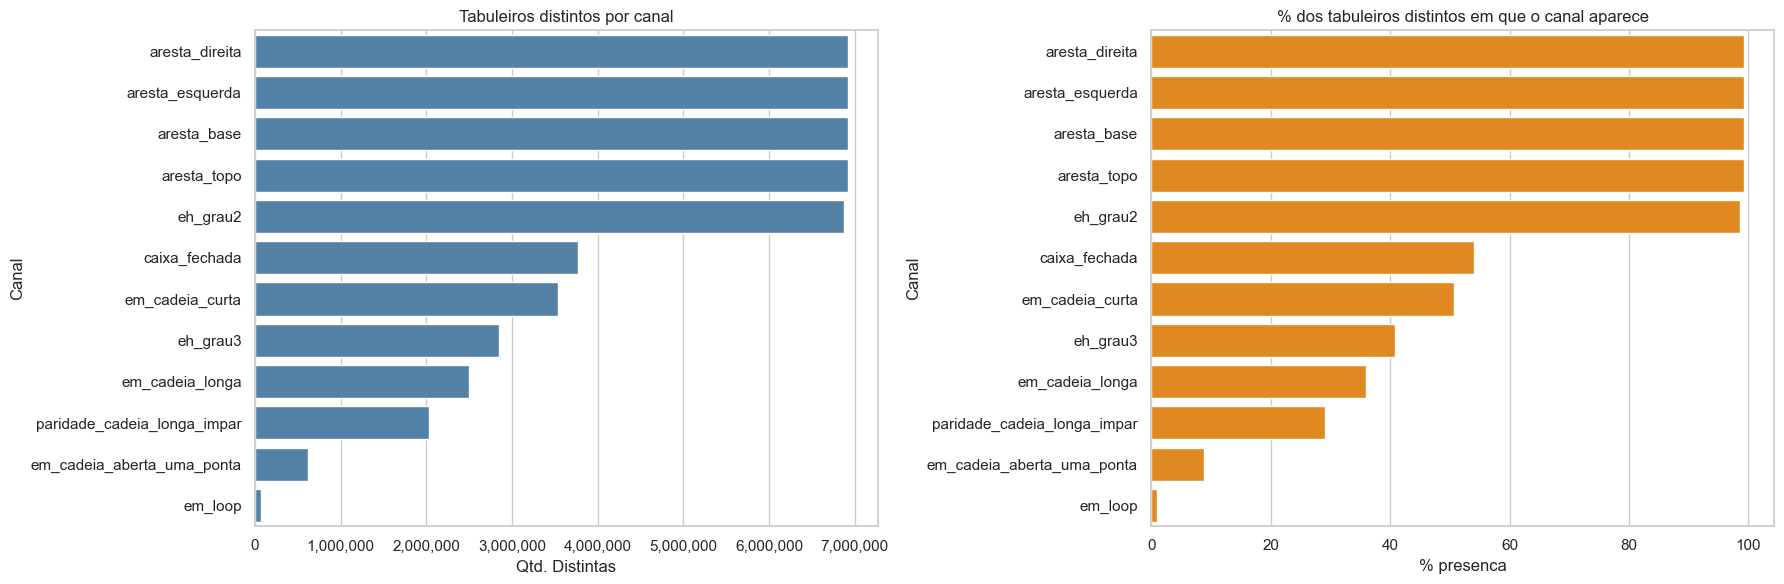

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ordem = df_canais.sort_values('Qtd. Distintas', ascending=False).reset_index(drop=True)
sns.barplot(data=ordem, y='Canal', x='Qtd. Distintas', ax=axes[0], color='steelblue')
axes[0].set_title('Tabuleiros distintos por canal')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ordem['% presenca'] = 100 * ordem['Qtd. Distintas'] / len(df_dist)
sns.barplot(data=ordem, y='Canal', x='% presenca', ax=axes[1], color='darkorange')
axes[1].set_title('% dos tabuleiros distintos em que o canal aparece')
plt.tight_layout(); plt.show()

### Co-ocorrência entre canais

Cada célula = P(canal da linha presente | canal da coluna presente), sobre tabuleiros distintos. Leia por coluna: "dado que o canal X aparece, com que frequência o canal Y também aparece?".

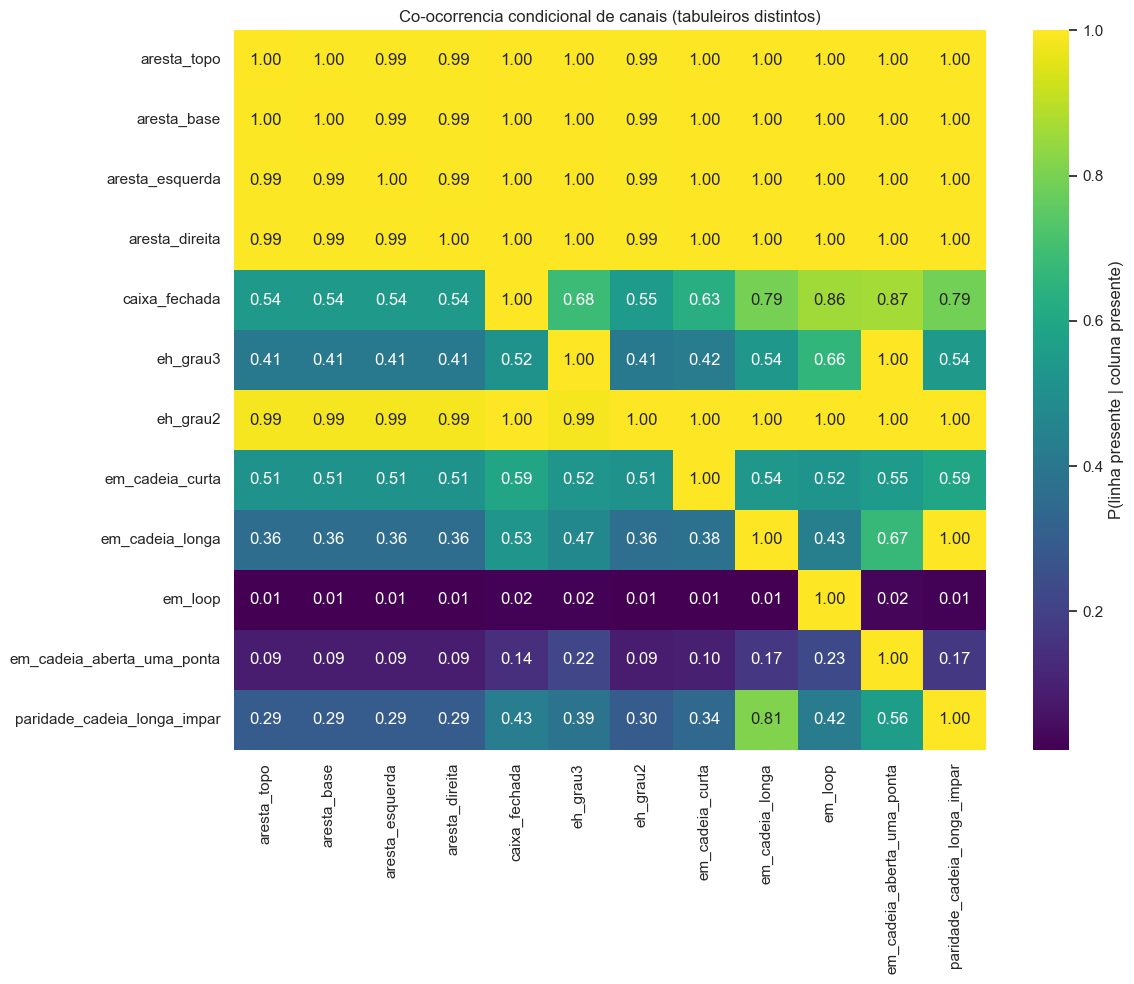

In [31]:
M = df_dist[ch_cols].values.astype(bool)
base = M.sum(axis=0)
co = np.zeros((len(NOMES), len(NOMES)))
for i in range(len(NOMES)):
    for j in range(len(NOMES)):
        co[i, j] = (M[:, i] & M[:, j]).sum() / base[j] if base[j] else 0.0
plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(co, index=NOMES, columns=NOMES), annot=True, fmt='.2f',
            cmap='viridis', cbar_kws={'label': 'P(linha presente | coluna presente)'})
plt.title('Co-ocorrencia condicional de canais (tabuleiros distintos)')
plt.tight_layout(); plt.show()

### Ativação dos canais por fase do jogo

Fração dos tabuleiros distintos de cada fase (`qtd_tracos`) em que o canal aparece. Revela *quando* cada estrutura emerge ao longo da partida (ex.: cadeias longas e meias-pontas só surgem no fim).

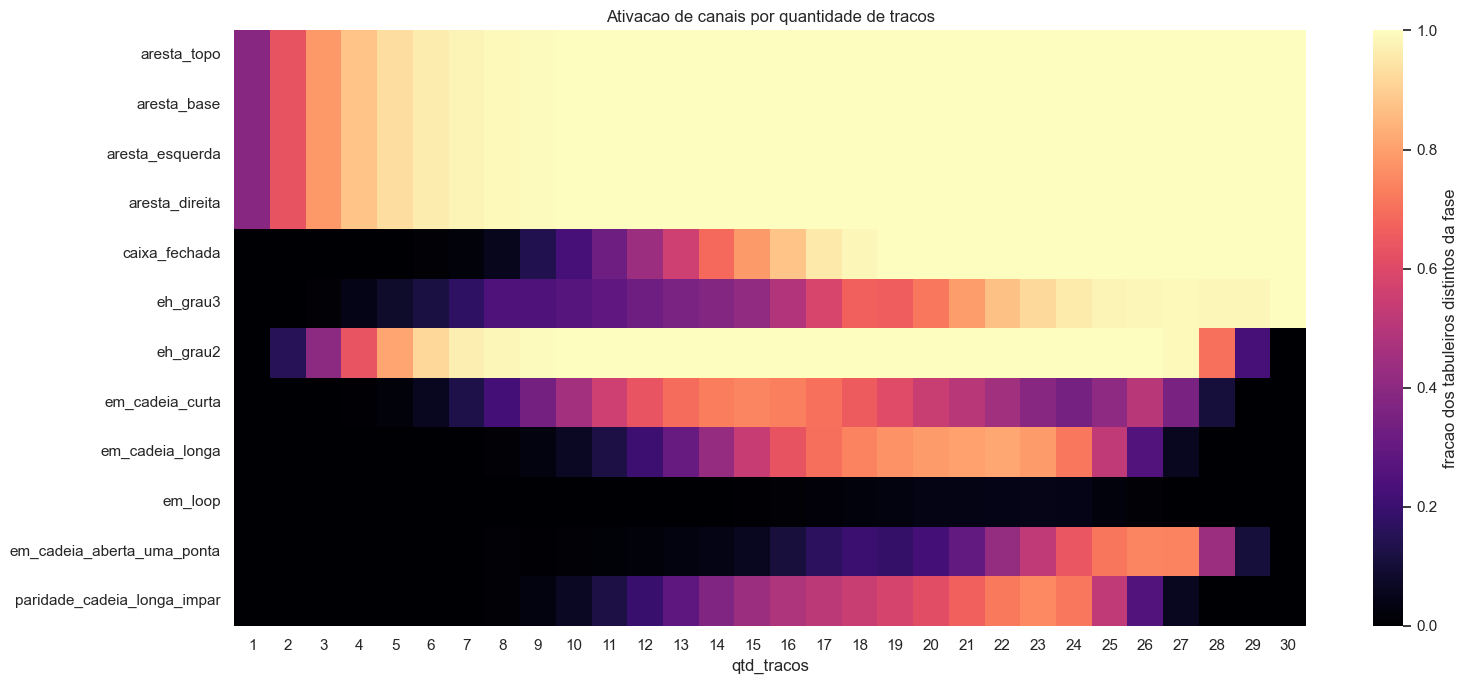

In [32]:
fases = sorted(df_dist['qtd_tracos'].unique())
mat = np.zeros((len(NOMES), len(fases)))
for fi, t in enumerate(fases):
    sub = df_dist[df_dist['qtd_tracos'] == t]
    for ki, c in enumerate(ch_cols):
        mat[ki, fi] = sub[c].mean() if len(sub) else 0.0
plt.figure(figsize=(16, 7))
sns.heatmap(pd.DataFrame(mat, index=NOMES, columns=fases), cmap='magma',
            cbar_kws={'label': 'fracao dos tabuleiros distintos da fase'})
plt.title('Ativacao de canais por quantidade de tracos')
plt.xlabel('qtd_tracos'); plt.tight_layout(); plt.show()

## 2. Conferência de `score_melhor_jogada`

Usando apenas pares distintos `(tabuleiro, score)`:
- **Item 1**: para um dado vetor `score_melhor_jogada`, quantos tabuleiros distintos o possuem? (intuição: pouquíssimos)
- **Item 2**: para um dado tabuleiro, quantos vetores `score_melhor_jogada` distintos existem? (esperado: exatamente 1, pois o oráculo é exato e determinístico)

In [33]:
pares = df[['board_id', 'score_id']].drop_duplicates()
por_board = pares.groupby('board_id')['score_id'].nunique()
por_score = pares.groupby('score_id')['board_id'].nunique()

print("ITEM 2 - determinismo (1 tabuleiro -> N scores)")
print(f"  Tabuleiros distintos ................. {por_board.shape[0]:,}")
print(f"  Com >1 score distinto (anomalias) .... {int((por_board > 1).sum()):,}")
print(f"  Maximo de scores p/ um tabuleiro ..... {int(por_board.max())}")
print()
print("ITEM 1 - coincidencia (1 score -> N tabuleiros)")
print(f"  Vetores de score distintos ........... {por_score.shape[0]:,}")
print(f"  Compartilhados por >1 tabuleiro ...... {int((por_score > 1).sum()):,}")
print(f"  Maximo de tabuleiros p/ um score ..... {int(por_score.max())}")
print()
print("=> Bijecao perfeita: cada vetor score_melhor_jogada identifica 1 unico tabuleiro,")
print("   e cada tabuleiro tem exatamente 1 vetor. O score e uma 'impressao digital' do estado.")

# Visao relaxada: ignora a POSICAO da jogada; compara so o conjunto (multiset) de valores de score.
por_vs = df[['board_id', 'valset_id']].drop_duplicates().groupby('valset_id')['board_id'].nunique()
em_colisao = int(por_vs[por_vs > 1].sum())
print("\nVISAO RELAXADA - ignorando a posicao da jogada (so o conjunto de valores de score):")
print(f"  Conjuntos de valores distintos ....... {por_vs.shape[0]:,}")
print(f"  Conjuntos com >1 tabuleiro ........... {int((por_vs > 1).sum()):,}")
print(f"  Tabuleiros distintos em colisao ...... {em_colisao:,} ({100*em_colisao/len(df_dist):.1f}%)")
print("  -> A unicidade vem da GEOMETRIA (quais arestas estao livres), nao dos valores.")

ITEM 2 - determinismo (1 tabuleiro -> N scores)
  Tabuleiros distintos ................. 6,967,123
  Com >1 score distinto (anomalias) .... 0
  Maximo de scores p/ um tabuleiro ..... 1

ITEM 1 - coincidencia (1 score -> N tabuleiros)
  Vetores de score distintos ........... 6,967,123
  Compartilhados por >1 tabuleiro ...... 0
  Maximo de tabuleiros p/ um score ..... 1

=> Bijecao perfeita: cada vetor score_melhor_jogada identifica 1 unico tabuleiro,
   e cada tabuleiro tem exatamente 1 vetor. O score e uma 'impressao digital' do estado.

VISAO RELAXADA - ignorando a posicao da jogada (so o conjunto de valores de score):
  Conjuntos de valores distintos ....... 203,536
  Conjuntos com >1 tabuleiro ........... 203,533
  Tabuleiros distintos em colisao ...... 6,967,120 (100.0%)
  -> A unicidade vem da GEOMETRIA (quais arestas estao livres), nao dos valores.


### Entendendo a "visão relaxada"

O `score_melhor_jogada` é um vetor de 31 posições, uma por aresta específica do tabuleiro. Posições de arestas já jogadas valem `-1e9` (inválidas); as livres carregam o valor exato do oráculo.

- **Itens 1 e 2 (exatos)** comparam o vetor inteiro, incluindo em qual posição cada valor está. Deu bijeção: cada vetor pertence a exatamente 1 tabuleiro. Faz sentido, porque quais posições estão livres já descreve a geometria do tabuleiro.
- **Visão relaxada** joga fora a posição e olha só o conjunto de valores (por exemplo, "este tabuleiro tem os scores {+2, +2, 0, -1}", sem dizer em quais arestas).

O que ela revela: boa parte dos tabuleiros distintos compartilha seu conjunto de valores com algum outro tabuleiro (a porcentagem exata aparece na saída da célula anterior). Ou seja, os números de score se repetem bastante entre tabuleiros diferentes; o que torna cada vetor único não são os valores, e sim onde eles estão (a geometria das arestas livres).

## 3. Cadeias Longas

Visão sobre os campos escalares `qtd_cadeias_longas`, `total_caixas_cadeias_longas` e `tamanho_max_cadeia_longa` (tabuleiros distintos). O valor `prof_min = total_caixas + 2*qtd_cadeias` indica a profundidade mínima que uma busca Minimax precisaria para resolver as cadeias. Como aqui os rótulos vêm do oráculo exato, todos os estados já estão resolvidos, qualquer que seja o tamanho das cadeias.

Distribuicao do numero de cadeias longas (tabuleiros distintos):
  0 cadeia(s):  4,465,448  (64.09%)
  1 cadeia(s):  2,020,644  (29.00%)
  2 cadeia(s):    469,741  ( 6.74%)
  3 cadeia(s):     11,290  ( 0.16%)

Tabuleiros com >=1 cadeia longa .... 2,501,675 (35.9%)
Media de caixas por cadeia ......... 3.81
prof_min > 11 (exigiriam busca profunda num Minimax) .. 162,902 (2.34%)


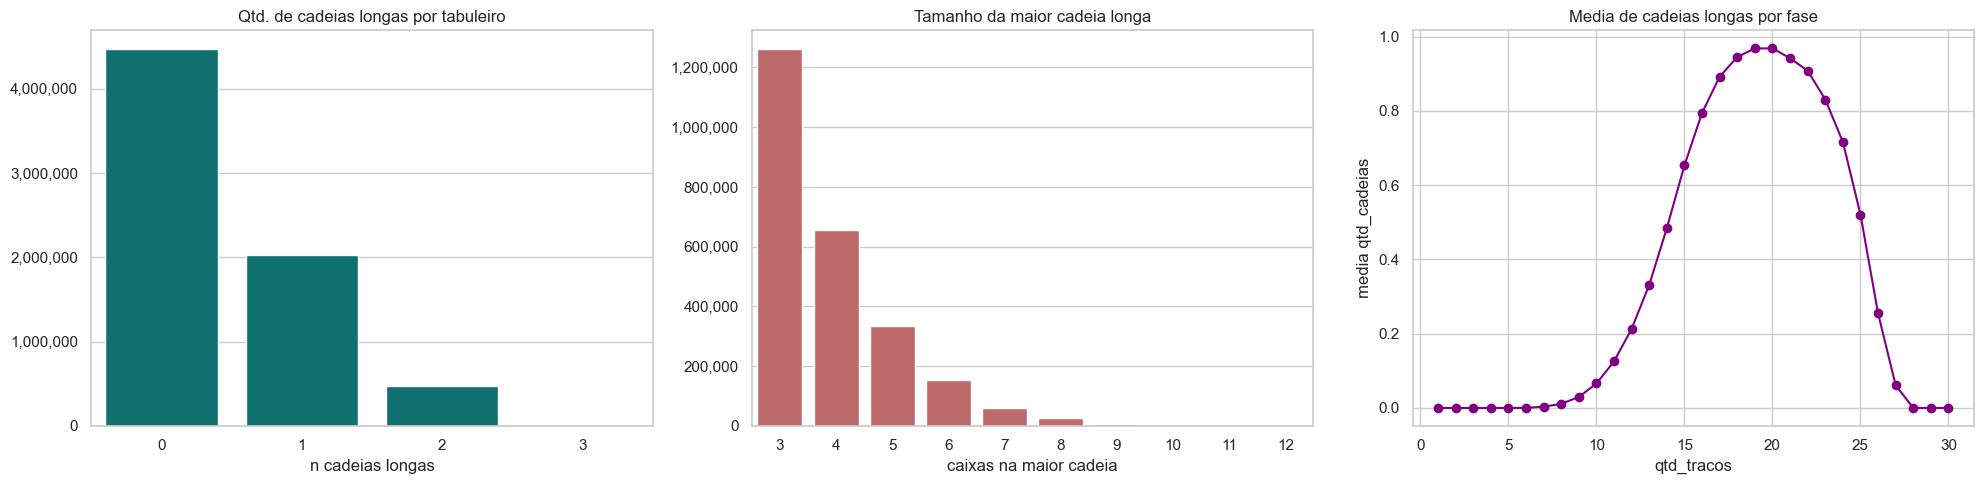

In [34]:
dd = df_dist.copy()
dd['prof_min'] = dd['total_caixas'] + 2 * dd['qtd_cadeias']
tot = len(dd)

print("Distribuicao do numero de cadeias longas (tabuleiros distintos):")
vc = dd['qtd_cadeias'].value_counts().sort_index()
for k, v in vc.items():
    print(f"  {k} cadeia(s): {v:>10,}  ({100*v/tot:5.2f}%)")
com = dd[dd['qtd_cadeias'] > 0]
print(f"\nTabuleiros com >=1 cadeia longa .... {len(com):,} ({100*len(com)/tot:.1f}%)")
print(f"Media de caixas por cadeia ......... {(com['total_caixas']/com['qtd_cadeias']).mean():.2f}")
print(f"prof_min > 11 (exigiriam busca profunda num Minimax) .. {int((dd['prof_min']>11).sum()):,} ({100*(dd['prof_min']>11).mean():.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=vc.index, y=vc.values, ax=axes[0], color='teal')
axes[0].set_title('Qtd. de cadeias longas por tabuleiro'); axes[0].set_xlabel('n cadeias longas')
tm = com['tam_max'].value_counts().sort_index()
sns.barplot(x=tm.index, y=tm.values, ax=axes[1], color='indianred')
axes[1].set_title('Tamanho da maior cadeia longa'); axes[1].set_xlabel('caixas na maior cadeia')
pc = dd.groupby('qtd_tracos')['qtd_cadeias'].mean()
axes[2].plot(pc.index, pc.values, marker='o', color='purple')
axes[2].set_title('Media de cadeias longas por fase'); axes[2].set_xlabel('qtd_tracos'); axes[2].set_ylabel('media qtd_cadeias')
for a in axes[:2]:
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()

### O oráculo resolve todos os estados, inclusive os de cadeia longa?

Como o rótulo vem do oráculo exato, `depth_melhor_jogada` é sempre a distância até o fim do jogo (`31 - qtd_tracos`), ou seja, todo estado é avaliado enxergando a partida inteira. A verificação abaixo confirma isso e, em particular, que os estados com cadeia longa (`qtd_cadeias_longas >= 1`), os mais difíceis de resolver por busca truncada, estão todos rotulados até o fechamento completo das cadeias.

In [35]:
cad = df_dist[df_dist['qtd_cadeias'] >= 1].copy()
cad['prof_min'] = cad['total_caixas'] + 2 * cad['qtd_cadeias']
viu_fim = bool((df_dist['depth_mj'] == df_dist['arestas_livres']).all())
n = len(cad)

print(f"Estados distintos COM cadeia longa (qtd_cadeias_longas >= 1) .. {n:,}")
print(f"depth_melhor_jogada == arestas_livres em todos os estados ..... {viu_fim}")
print("  O oraculo enxerga ate o fim do jogo em 100% dos casos, inclusive")
print("  nos estados de cadeia longa, que sao os mais dificeis de resolver.")
print()
exigem_profundo = int((cad['prof_min'] > 11).sum())
print(f"Cadeias longas que um Minimax so resolveria com profundidade > 11: {exigem_profundo:,} ({100*exigem_profundo/max(n,1):.1f}%)")
print("Com o oraculo, todos esses estados ja estao rotulados de forma exata.")

Estados distintos COM cadeia longa (qtd_cadeias_longas >= 1) .. 2,501,675
depth_melhor_jogada == arestas_livres em todos os estados ..... True
  O oraculo enxerga ate o fim do jogo em 100% dos casos, inclusive
  nos estados de cadeia longa, que sao os mais dificeis de resolver.

Cadeias longas que um Minimax so resolveria com profundidade > 11: 162,902 (6.5%)
Com o oraculo, todos esses estados ja estao rotulados de forma exata.


## 4. Faixa de Score por distância ao terminal

`arestas_livres = 31 - qtd_tracos` é o número de traços que ainda faltam, e equivale à distância até o fim do jogo. Para cada valor de arestas livres, mostramos o maior e o menor valor de `score_melhor_jogada`.

Como o oráculo resolve a partida por completo, cada score é o valor exato do jogo (a diferença final de caixas sob jogo ótimo), e não uma estimativa truncada. O domínio observado é [-12, 12]. O extremo +12 aparece porque um único traço pode fechar duas caixas de uma vez e porque fechar uma caixa dá um lance extra ao mesmo jogador, o que permite encadear capturas: perto do fim, a diferença de caixas a favor de quem joga pode chegar a 12.

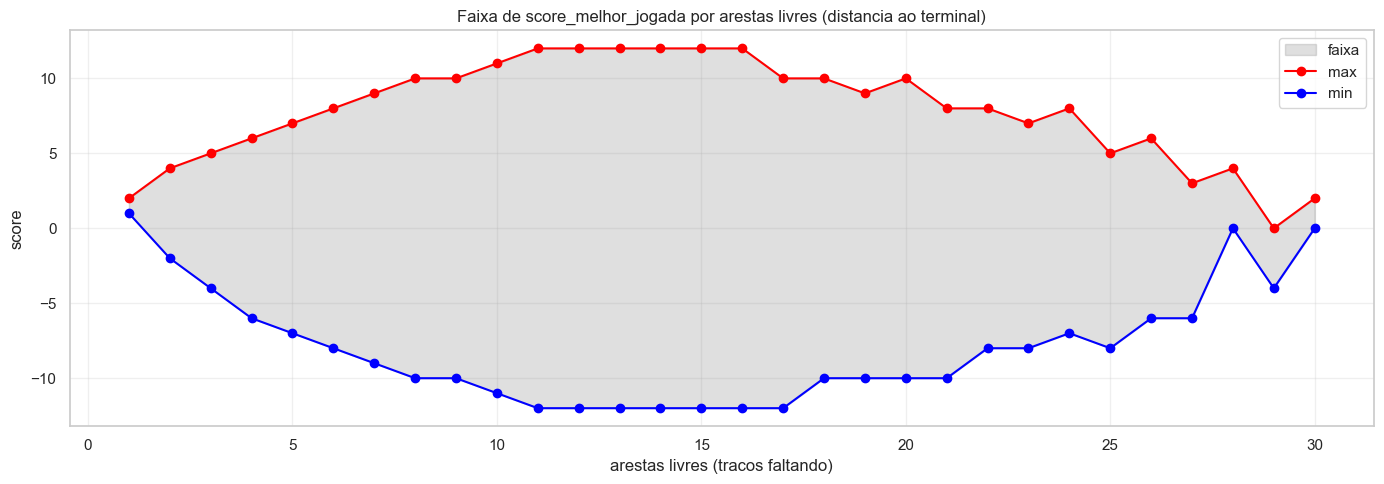

arestas_livres,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
max_score,2.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,10.0,11.0,...,8.0,8.0,7.0,8.0,5.0,6.0,3.0,4.0,0.0,2.0
min_score,1.0,-2.0,-4.0,-6.0,-7.0,-8.0,-9.0,-10.0,-10.0,-11.0,...,-10.0,-8.0,-8.0,-7.0,-8.0,-6.0,-6.0,0.0,-4.0,0.0


In [36]:
faixa = df.groupby('arestas_livres').agg(max_score=('score_max', 'max'), min_score=('score_min', 'min'))

plt.figure(figsize=(14, 5))
plt.fill_between(faixa.index, faixa['min_score'], faixa['max_score'], alpha=0.25, color='gray', label='faixa')
plt.plot(faixa.index, faixa['max_score'], marker='o', color='red', label='max')
plt.plot(faixa.index, faixa['min_score'], marker='o', color='blue', label='min')
plt.title('Faixa de score_melhor_jogada por arestas livres (distancia ao terminal)')
plt.xlabel('arestas livres (tracos faltando)'); plt.ylabel('score'); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

display(faixa.T)

## 5. Visões adicionais

Visões complementares, relevantes para o treino da CNN:

1. Balanceamento dos rótulos (`melhor_jogada`): distribuição da classe-alvo. Desbalanceamento sugere uso de `class_weight`.
2. Margem de decisão e empates: `score_max - score_2nd`. Quando vale 0 há duas ou mais jogadas ótimas empatadas e o alvo argmax é arbitrário. Quando a fração de estados com empate é alta (ver saída adiante), há forte argumento para soft targets (treinar contra a distribuição de scores) e para avaliar top-k em vez do acerto exato do argmax.
3. Eficiência do gerador por fase: razão distintas/brutas, ou seja, quanto da simulação é desperdiçado em duplicatas em cada fase.

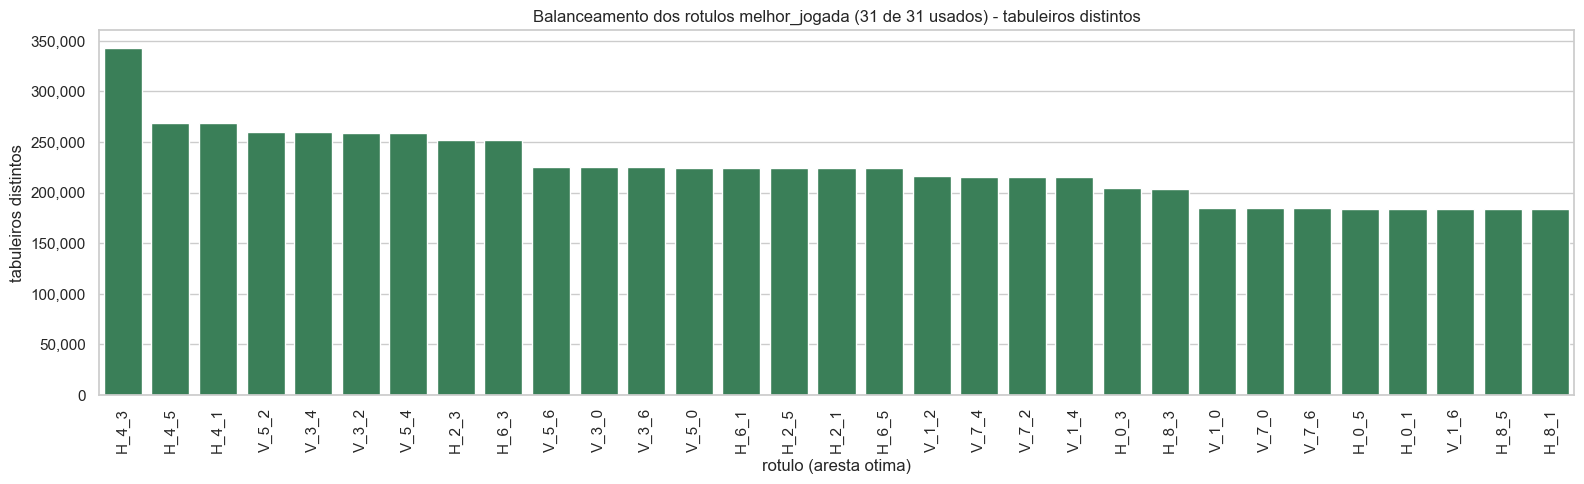

Razao de frequencia entre o rotulo mais e o menos comum: 1.87x


In [37]:
vc = df_dist['melhor_jogada'].value_counts()
plt.figure(figsize=(16, 5))
sns.barplot(x=vc.index, y=vc.values, color='seagreen')
plt.title(f'Balanceamento dos rotulos melhor_jogada ({vc.shape[0]} de 31 usados) - tabuleiros distintos')
plt.xticks(rotation=90); plt.ylabel('tabuleiros distintos'); plt.xlabel('rotulo (aresta otima)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()
print(f"Razao de frequencia entre o rotulo mais e o menos comum: {vc.max()/vc.min():.2f}x")

Estados com >1 jogada valida ...... 8,275,578
  com empate exato (margem=0) ..... 4,147,930 (50.1%)
  margem media .................... 1.53
  margem mediana .................. 0.0


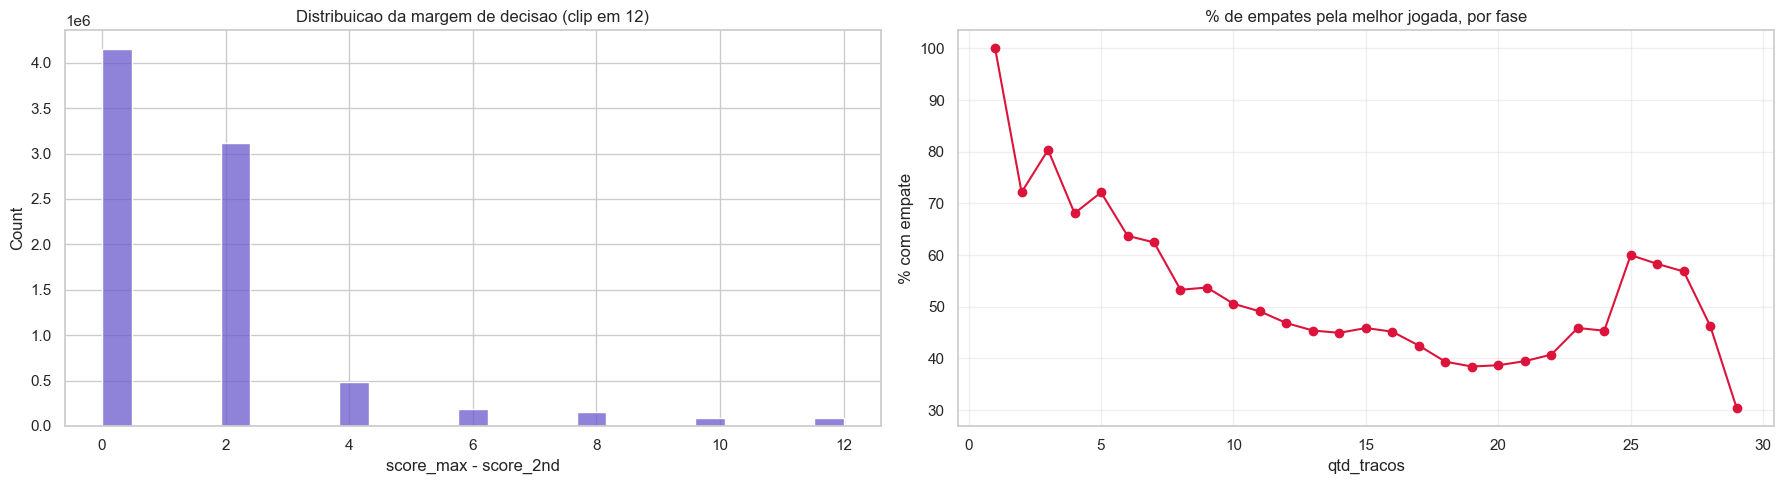

In [38]:
multi = df[df['n_validos'] > 1].copy()
multi['empate'] = multi['margem'] == 0
print(f"Estados com >1 jogada valida ...... {len(multi):,}")
print(f"  com empate exato (margem=0) ..... {int(multi['empate'].sum()):,} ({100*multi['empate'].mean():.1f}%)")
print(f"  margem media .................... {multi['margem'].mean():.2f}")
print(f"  margem mediana .................. {multi['margem'].median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(multi['margem'].clip(upper=12), bins=25, ax=axes[0], color='slateblue')
axes[0].set_title('Distribuicao da margem de decisao (clip em 12)')
axes[0].set_xlabel('score_max - score_2nd')
taxa = multi.groupby('qtd_tracos')['empate'].mean()
axes[1].plot(taxa.index, 100 * taxa.values, marker='o', color='crimson')
axes[1].set_title('% de empates pela melhor jogada, por fase')
axes[1].set_xlabel('qtd_tracos'); axes[1].set_ylabel('% com empate'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

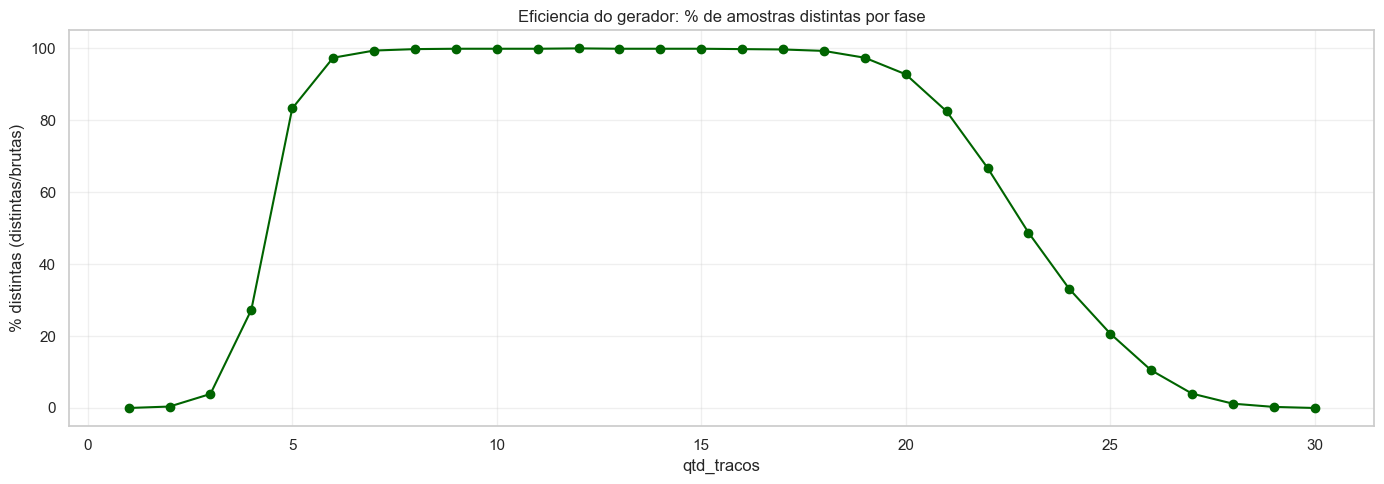

,brutas,distintas,% distintas
qtd_tracos,,,
1,114116,31,0.0
2,114116,465,0.4
3,114116,4495,3.9
4,115069,31465,27.3
5,188292,156915,83.3
6,345462,336597,97.4
7,421682,418974,99.4
8,448115,447202,99.8
9,456404,455868,99.9


In [39]:
bruta = df.groupby('qtd_tracos').size()
dist = df_dist.groupby('qtd_tracos').size()
red = pd.DataFrame({'brutas': bruta, 'distintas': dist})
red['% distintas'] = (100 * red['distintas'] / red['brutas']).round(1)
plt.figure(figsize=(14, 5))
plt.plot(red.index, red['% distintas'], marker='o', color='darkgreen')
plt.title('Eficiencia do gerador: % de amostras distintas por fase')
plt.xlabel('qtd_tracos'); plt.ylabel('% distintas (distintas/brutas)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
display(red)

### Média de arestas empatadas em 1º lugar, por fase

Para cada tabuleiro distinto, conta quantas arestas atingem o **maior** valor de `score_melhor_jogada` - isto é, quantas jogadas são *co-ótimas* (empatadas em 1º lugar). O gráfico mostra a média dessa contagem por `qtd_tracos`. Complementa a visão de empates: aqui medimos *quantas* jogadas empatam no topo, não só se há empate. Apenas amostras distintas.

Interpretação: no início (poucos traços) o tabuleiro é quase simétrico e muitas arestas são equivalentes; a contagem cai no meio-jogo (decisões mais "amarradas") e volta a 1 no fim (resta 1 jogada).

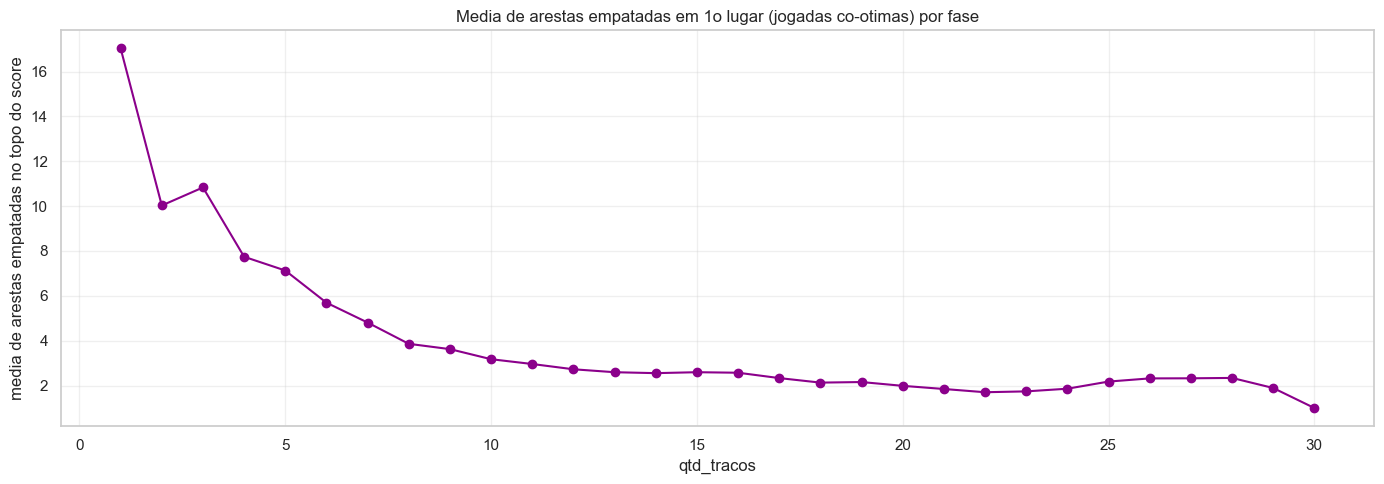

,mean,median,max
qtd_tracos,,,
1,17.03,18.0,30
2,10.03,10.0,27
3,10.83,9.0,28
4,7.74,5.0,27
5,7.13,4.0,26
6,5.69,3.0,25
7,4.81,2.0,24
8,3.86,2.0,23
9,3.62,2.0,22


In [40]:
g = df_dist.groupby('qtd_tracos')['n_top'].mean()
plt.figure(figsize=(14, 5))
plt.plot(g.index, g.values, marker='o', color='darkmagenta')
plt.title('Media de arestas empatadas em 1o lugar (jogadas co-otimas) por fase')
plt.xlabel('qtd_tracos'); plt.ylabel('media de arestas empatadas no topo do score')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
display(df_dist.groupby('qtd_tracos')['n_top'].agg(['mean', 'median', 'max']).round(2))